# Functions


In [5]:
def compute_distances_no_loops(x_train: torch.Tensor, x_test: torch.Tensor):
    """
    Computes the squared Euclidean distance between each element of training
    set and each element of test set. Images should be flattened and treated
    as vectors.

    This implementation should not use any Python loops. For memory-efficiency,
    it also should not create any large intermediate tensors; in particular you
    should not create any intermediate tensors with O(num_train * num_test)
    elements.

    Similar to `compute_distances_two_loops`, this should be able to handle
    inputs with any number of dimensions. The inputs should not be modified.

    NOTE: Your implementation may not use `torch.norm`, `torch.dist`,
    `torch.cdist`, or their instance method variants (`x.norm`, `x.dist`,
    `x.cdist`, etc.). You may not use any functions from `torch.nn` or
    `torch.nn.functional` modules.

    Args:
        x_train: Tensor of shape (num_train, C, H, W)
        x_test: Tensor of shape (num_test, C, H, W)

    Returns:
        dists: Tensor of shape (num_train, num_test) where dists[i, j] is
            the squared Euclidean distance between the i-th training point and
            the j-th test point.
    """
    # Initialize dists to be a tensor of shape (num_train, num_test) with the
    # same datatype and device as x_train
    num_train = x_train.shape[0]
    num_test = x_test.shape[0]
    dists = x_train.new_zeros(num_train, num_test)
    ##########################################################################
    # TODO: Implement this function without using any explicit loops and     #
    # without creating any intermediate tensors with O(num_train * num_test) #
    # elements.                                                              #
    #                                                                        #
    # You may not use torch.norm (or its instance method variant), nor any   #
    # functions from torch.nn or torch.nn.functional.                        #
    #                                                                        #
    # HINT: Try to formulate the Euclidean distance using two broadcast sums #
    #       and a matrix multiply.                                           #
    ##########################################################################
    # Replace "pass" statement with your code
    x_train_flat = x_train.reshape(num_train, -1)
    x_test_flat = x_test.reshape(num_test, -1)

    train_squares = torch.sum(x_train_flat ** 2, dim=1, keepdim=True)
    test_squares = torch.sum(x_test_flat ** 2, dim=1)

    cross_term = torch.mm(x_train_flat, x_test_flat.t())

    dists = train_squares - 2 * cross_term + test_squares
    ##########################################################################
    #                           END OF YOUR CODE                             #
    ##########################################################################
    return dists


In [1]:
def hello():
    """
    This is a sample function that we will try to import and run to ensure that
    our environment is correctly set up.
    """
    print("Hello from knn.py!")


In [8]:
def predict_labels(dists: torch.Tensor, y_train: torch.Tensor, k: int = 1):
    """
    Given distances between all pairs of training and test samples, predict a
    label for each test sample by taking a MAJORITY VOTE among its `k` nearest
    neighbors in the training set.

    In the event of a tie, this function SHOULD return the smallest label. For
    example, if k=5 and the 5 nearest neighbors to a test example have labels
    [1, 2, 1, 2, 3] then there is a tie between 1 and 2 (each have 2 votes),
    so we should return 1 since it is the smallest label.

    This function should not modify any of its inputs.

    Args:
        dists: Tensor of shape (num_train, num_test) where dists[i, j] is the
            squared Euclidean distance between the i-th training point and the
            j-th test point.
        y_train: Tensor of shape (num_train,) giving labels for all training
            samples. Each label is an integer in the range [0, num_classes - 1]
        k: The number of nearest neighbors to use for classification.

    Returns:
        y_pred: int64 Tensor of shape (num_test,) giving predicted labels for
            the test data, where y_pred[j] is the predicted label for the j-th
            test example. Each label should be an integer in the range
            [0, num_classes - 1].
    """
    num_train, num_test = dists.shape
    y_pred = torch.zeros(num_test, dtype=torch.int64)
    ##########################################################################
    # TODO: Implement this function. You may use an explicit loop over the   #
    # test samples.                                                          #
    #                                                                        #
    # HINT: Look up the function torch.topk                                  #
    ##########################################################################
    # Replace "pass" statement with your code
    _, closest_indices = torch.topk(dists, k, dim=0, largest=False)
    closest_labels = y_train[closest_indices.t()]

    for j in range(num_test):
      votes = torch.bincount(closest_labels[j])
      y_pred[j] = torch.argmax(votes)
    ##########################################################################
    #                           END OF YOUR CODE                             #
    ##########################################################################
    return y_pred


In [11]:
class KnnClassifier:

    def __init__(self, x_train: torch.Tensor, y_train: torch.Tensor):
        """
        Create a new K-Nearest Neighbor classifier with the specified training
        data. In the initializer we simply memorize the provided training data.

        Args:
            x_train: Tensor of shape (num_train, C, H, W) giving training data
            y_train: int64 Tensor of shape (num_train, ) giving training labels
        """
        ######################################################################
        # TODO: Implement the initializer for this class. It should perform  #
        # no computation and simply memorize the training data in            #
        # `self.x_train` and `self.y_train`, accordingly.                    #
        ######################################################################
        # Replace "pass" statement with your code
        self.x_train = x_train
        self.y_train = y_train
        ######################################################################
        #                         END OF YOUR CODE                           #
        ######################################################################

    def predict(self, x_test: torch.Tensor, k: int = 1):
        """
        Make predictions using the classifier.

        Args:
            x_test: Tensor of shape (num_test, C, H, W) giving test samples.
            k: The number of neighbors to use for predictions.

        Returns:
            y_test_pred: Tensor of shape (num_test,) giving predicted labels
                for the test samples.
        """
        y_test_pred = None
        ######################################################################
        # TODO: Implement this method. You should use the functions you      #
        # wrote above for computing distances (use the no-loop variant) and  #
        # to predict output labels.                                          #
        ######################################################################
        # Replace "pass" statement with your code
        dists = compute_distances_no_loops(self.x_train, x_test)
        y_test_pred = predict_labels(dists, self.y_train, k=k)
        ######################################################################
        #                         END OF YOUR CODE                           #
        ######################################################################
        return y_test_pred

    def check_accuracy(
        self,
        x_test: torch.Tensor,
        y_test: torch.Tensor,
        k: int = 1,
        quiet: bool = False
    ):
        """
        Utility method for checking the accuracy of this classifier on test
        data. Returns the accuracy of the classifier on the test data, and
        also prints a message giving the accuracy.

        Args:
            x_test: Tensor of shape (num_test, C, H, W) giving test samples.
            y_test: int64 Tensor of shape (num_test,) giving test labels.
            k: The number of neighbors to use for prediction.
            quiet: If True, don't print a message.

        Returns:
            accuracy: Accuracy of this classifier on the test data, as a
                percent. Python float in the range [0, 100]
        """
        y_test_pred = self.predict(x_test, k=k)
        num_samples = x_test.shape[0]
        num_correct = (y_test == y_test_pred).sum().item()
        accuracy = 100.0 * num_correct / num_samples
        msg = (
            f"Got {num_correct} / {num_samples} correct; "
            f"accuracy is {accuracy:.2f}%"
        )
        if not quiet:
            print(msg)
        return accuracy

# Lab 03: K-Nearest Neighbors - Classification

This lab continues directly from Lab 02. You will turn distance computations
into a complete k-NN classifier, study how the choice of `k` changes decision
boundaries, and evaluate `k=1` and `k=5` on CIFAR-10.

Before starting, copy your completed implementations of
`compute_distances_two_loops`, `compute_distances_one_loop`, and
`compute_distances_no_loops` from the Lab 02 `knn.py` into this lab's
`knn.py`. Do not copy output cells or solutions from another source.


## Setup

Run this cell from the `A1` directory. It imports the local support package and
checks that the lab file is visible.


In [4]:
import torch
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10.0, 8.0)
plt.rcParams["font.size"] = 16

hello()


Hello from knn.py!


## Confirm your Lab 02 distance function

This independent check must pass before you implement label prediction. If it
fails, revisit the distance functions you copied from Lab 02.


In [6]:
x_train_small = torch.tensor([[0.0, 0.0], [3.0, 4.0]], dtype=torch.float64)
x_test_small = torch.tensor([[0.0, 4.0], [3.0, 0.0]], dtype=torch.float64)
expected = torch.tensor([[16.0, 9.0], [9.0, 16.0]], dtype=torch.float64)
actual = compute_distances_no_loops(x_train_small, x_test_small)
assert torch.allclose(actual, expected), f"Expected {expected}, got {actual}"
print("Distance function ready for Lab 03.")


Distance function ready for Lab 03.


## Predict labels
Now that we have a method for computing distances between training and test examples, we need to implement a function that uses those distances together with the training labels to predict labels for test samples.

In the file `knn.py`, implement the function `predict_labels`.

In [9]:
torch.manual_seed(0)
dists = torch.tensor([
    [0.3, 0.4, 0.1],
    [0.1, 0.5, 0.5],
    [0.4, 0.1, 0.2],
    [0.2, 0.2, 0.4],
    [0.5, 0.3, 0.3],
])
y_train = torch.tensor([0, 1, 0, 1, 2])
y_pred_expected = torch.tensor([1, 0, 0])
y_pred = predict_labels(dists, y_train, k=3)
correct = y_pred.tolist() == y_pred_expected.tolist()
print('Correct: ', correct)

Correct:  True


Now we have implemented all the required functionality for the K-Nearest Neighbor classifier. In the file `knn.py`, complete the implementation of the `KnnClassifier` class.

We can get some intuition into the KNN classifier by visualizing its predictions on toy 2D data. Here we will generate some random training and test points in 2D, and assign random labels to the training points. We can then make predictions for the test points, and visualize both training and test points. Training points are shown as stars, and test points are shown as small transparent circles. The color of each point denotes its label -- ground-truth label for training points, and predicted label for test points.

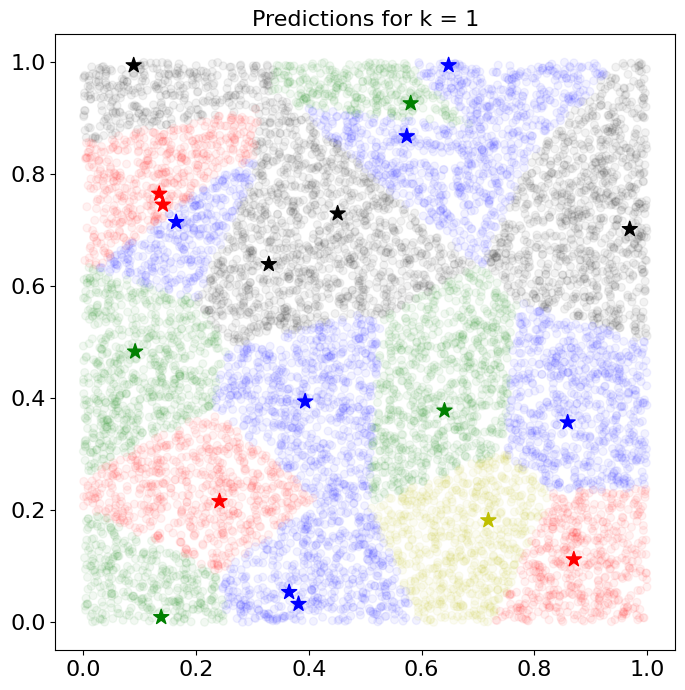

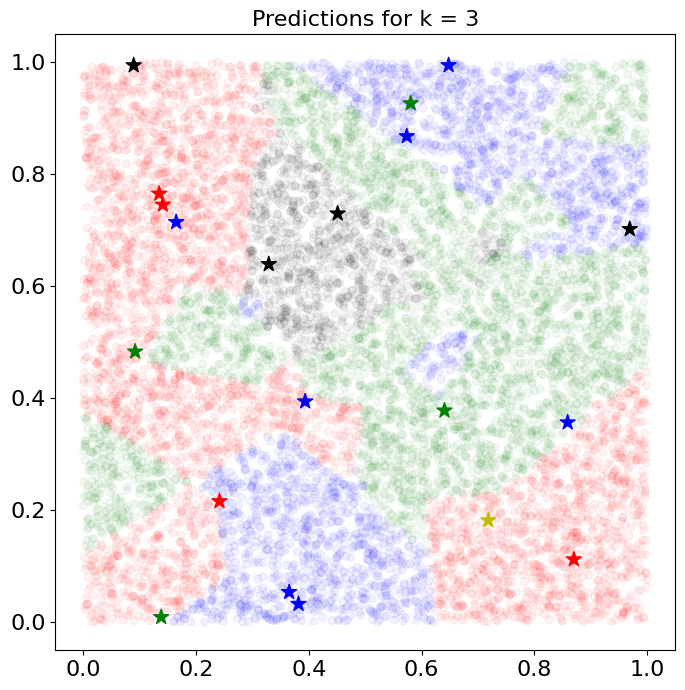

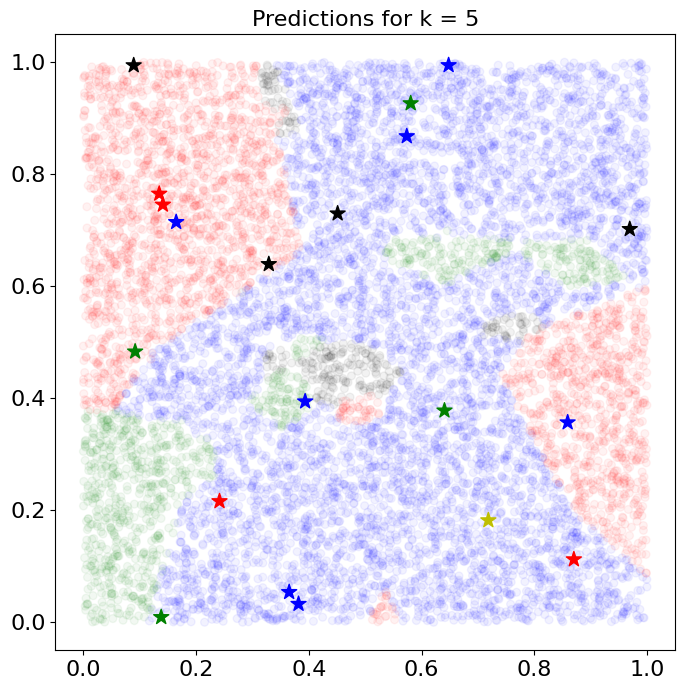

In [12]:
num_test = 10000
num_train = 20
num_classes = 5

# Generate random training and test data
torch.manual_seed(128)
x_train = torch.rand(num_train, 2)
y_train = torch.randint(num_classes, size=(num_train,))
x_test = torch.rand(num_test, 2)
classifier = KnnClassifier(x_train, y_train)

# Plot predictions for different values of k
for k in [1, 3, 5]:
    y_test = classifier.predict(x_test, k=k)
    plt.gcf().set_size_inches(8, 8)
    class_colors = ['r', 'g', 'b', 'k', 'y']
    train_colors = [class_colors[c] for c in y_train]
    test_colors = [class_colors[c] for c in y_test]
    plt.scatter(x_test[:, 0], x_test[:, 1],
                color=test_colors, marker='o', s=32, alpha=0.05)
    plt.scatter(x_train[:, 0], x_train[:, 1],
                color=train_colors, marker='*', s=128.0)
    plt.title('Predictions for k = %d' % k, size=16)
    plt.show()

We can use the exact same KNN code to perform image classification on CIFAR-10!

Now let's put everything together and test our k-NN classifier on a subset of CIFAR-10, using k=1:

If you've implemented everything correctly you should see an accuracy of about 27%.

In [15]:
import torchvision
import torchvision.transforms as transforms

In [16]:
torch.manual_seed(0)
num_train = 5000
num_test = 500

In [17]:
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

100%|██████████| 170M/170M [29:33<00:00, 96.1kB/s]


In [18]:
x_train = torch.stack([train_dataset[i][0] for i in range(num_train)])
y_train = torch.tensor([train_dataset[i][1] for i in range(num_train)], dtype=torch.int64)

x_test = torch.stack([test_dataset[i][0] for i in range(num_test)])
y_test = torch.tensor([test_dataset[i][1] for i in range(num_test)], dtype=torch.int64)

classifier = KnnClassifier(x_train, y_train)
classifier.check_accuracy(x_test, y_test, k=1)

Got 137 / 500 correct; accuracy is 27.40%


27.4

Now let's increase to k=5. You should see a slightly higher accuracy than k=1:

In [19]:
x_train = torch.stack([train_dataset[i][0] for i in range(num_train)])
y_train = torch.tensor([train_dataset[i][1] for i in range(num_train)], dtype=torch.int64)

x_test = torch.stack([test_dataset[i][0] for i in range(num_test)])
y_test = torch.tensor([test_dataset[i][1] for i in range(num_test)], dtype=torch.int64)

classifier = KnnClassifier(x_train, y_train)
classifier.check_accuracy(x_test, y_test, k=5)

Got 139 / 500 correct; accuracy is 27.80%


27.8

## Wrap-up

Record short answers before leaving:

1. How did the decision boundary change as `k` increased from 1 to 5?
2. Which value performed better on the CIFAR-10 subset?
3. Why is test-set accuracy not the right quantity for choosing `k`?

The homework continuation will use validation folds to choose `k` without
tuning on the test set.
